In [16]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [17]:
img = cv2.imread('pexels-alexravvas-26611787.jpg', cv2.IMREAD_GRAYSCALE)
resized_img = cv2.resize(img, (500, 500))
resized_img2 = resized_img.copy()

In [18]:
g_blur = cv2.GaussianBlur(resized_img, (5, 5), 1.4) # image, kernel size, sigma
canny_edges = cv2.Canny(g_blur, 100, 200, apertureSize=3) # image, lower threshold, upper threshold, size of Sobel kernel
laplacian_edges = cv2.Laplacian(g_blur,-1,ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT) # image, depth, kernel size, scale, delta, border type


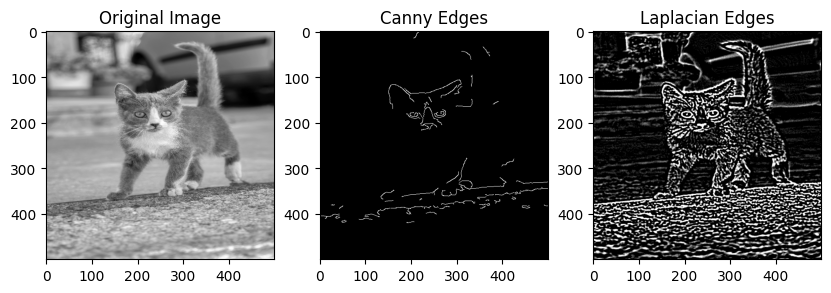

In [19]:
plt.figure(figsize=(10, 8))
plt.subplot(1, 3, 1)
plt.imshow(resized_img2, cmap='gray')
plt.title('Original Image')
plt.subplot(1, 3, 2)
plt.imshow(canny_edges, cmap='gray')
plt.title('Canny Edges')
plt.subplot(1, 3, 3)
plt.imshow(laplacian_edges, cmap='gray')
plt.title('Laplacian Edges')
plt.show()

In [20]:
pos4 = np.array([[0, 1, 0],
                [1, -4, 1],
                [0, 1, 0]], dtype=np.float32)

neg4 = np.array([[0, -1, 0],
                [-1, 4, -1],
                [0, -1, 0]], dtype=np.float32)

pos8 = np.array([[1, 1, 1],
                [1, -8, 1],
                [1, 1, 1]], dtype=np.float32)

neg8 = np.array([[-1, -1, -1],
                [-1, 8, -1],
                [-1, -1, -1]], dtype=np.float32)

In [21]:
lap_pos4 = cv2.filter2D(resized_img, -1, pos4) # image, depth means same output size as original, kernel
lap_neg4 = cv2.filter2D(resized_img, -1, neg4)
lap_pos8 = cv2.filter2D(resized_img, -1, pos8)
lap_neg8 = cv2.filter2D(resized_img, -1, neg8)

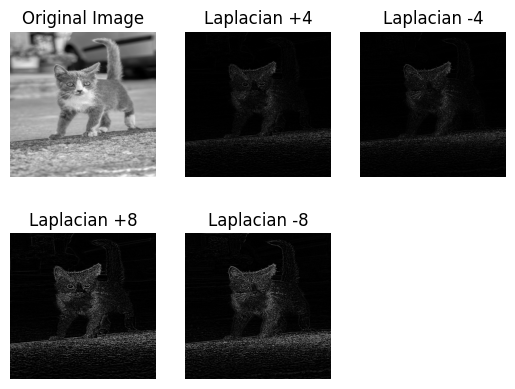

In [22]:
titles = ['Original Image', 'Laplacian +4', 'Laplacian -4', 'Laplacian +8', 'Laplacian -8']
images = [resized_img, lap_pos4, lap_neg4, lap_pos8, lap_neg8]

for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# **Task 1 images with 3 output types**

In [23]:
image16s = cv2.Laplacian(g_blur, cv2.CV_16S, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
image32f = cv2.Laplacian(g_blur, cv2.CV_32F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)
image8u = cv2.Laplacian(g_blur, cv2.CV_8U, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_DEFAULT)

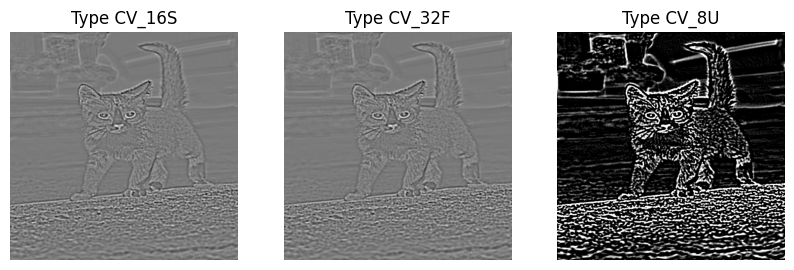

In [24]:
plt.figure(figsize=(10,5))
plt.subplot(131)
plt.imshow(image16s, cmap='gray')
plt.title('Type CV_16S')
plt.axis('off')
plt.subplot(132)
plt.imshow(image32f, cmap='gray')
plt.title('Type CV_32F')
plt.axis('off')
plt.subplot(133)
plt.imshow(image8u, cmap='gray')
plt.title('Type CV_8U')
plt.axis('off')
plt.show()

# **Task 2 Border Types**

In [25]:
#pad with consntant value (0)
constant = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_CONSTANT)
#pad with replication of the last pixel
replicate = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_REPLICATE)
#pad with reflection(mirror) of the border pixels
reflect = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_REFLECT)
#pad with reflection(mirror) of the border pixels, but without repeating the last pixel
reflect_101 = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_REFLECT_101)

#OpenCV does NOT allow BORDER_WRAP directly in cv2.Laplacian()
#So we manually pad using copyMakeBorder
padded = cv2.copyMakeBorder(g_blur, 2, 2, 2, 2, borderType=cv2.BORDER_WRAP)
wrap = cv2.Laplacian(padded, cv2.CV_64F, ksize=5)
wrap = wrap[2:-2, 2:-2]  # crop back to original size

# BORDER_TRANSPARENT is not properly supported in many filters like Laplacian
# So we simulate it by removing border influence
transparent = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, borderType=cv2.BORDER_REFLECT)
# simulate transparent by ignoring borders
transparent[0:2, :] = 0
transparent[-2:, :] = 0
transparent[:, 0:2] = 0
transparent[:, -2:] = 0

#used with ROI (Region of Interest) to ignore borders
isolated = cv2.Laplacian(g_blur, cv2.CV_64F, ksize=5, scale=1, delta=0, borderType=cv2.BORDER_ISOLATED)

In [26]:
# kernel size = 5 → padding = 2
pad = 2

# Step 1: add constant border with value 155
padded = cv2.copyMakeBorder(
    g_blur,
    pad, pad, pad, pad,
    borderType=cv2.BORDER_CONSTANT,
    value=155
)

# Step 2: apply Laplacian
laplacian_155 = cv2.Laplacian(padded, cv2.CV_64F, ksize=5)

# Step 3: crop back to original size
laplacian_155 = laplacian_155[pad:-pad, pad:-pad]

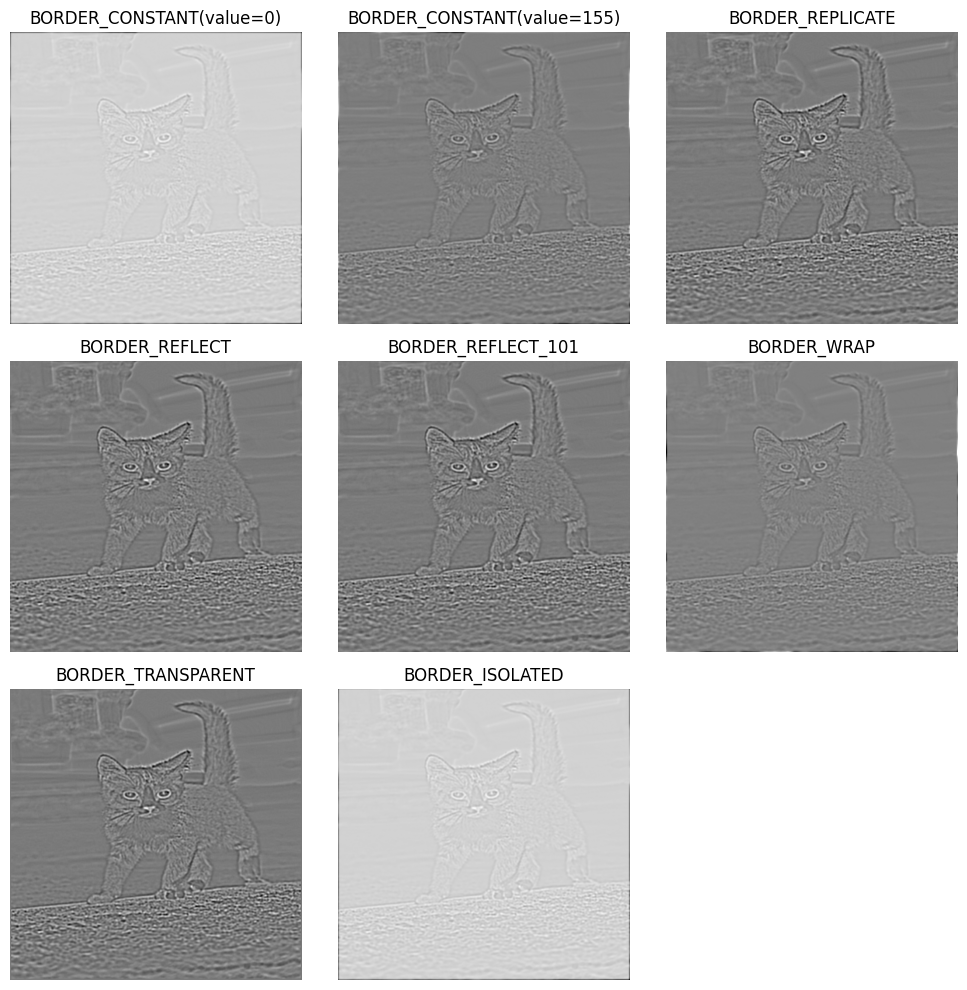

In [27]:
plt.figure(figsize=(10, 10))
titles = ['BORDER_CONSTANT(value=0)','BORDER_CONSTANT(value=155)', 'BORDER_REPLICATE', 'BORDER_REFLECT', 'BORDER_REFLECT_101', 'BORDER_WRAP', 'BORDER_TRANSPARENT', 'BORDER_ISOLATED']
images = [constant, laplacian_155, replicate, reflect, reflect_101, wrap, transparent, isolated]
for i in range(8):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')
plt.tight_layout()
plt.show()